# Unveiling the Android App Market — Google Play Store Analysis
### Oasis Infobyte — Data Analytics Internship | Level 2, Task 4

**Objective:** Perform a comprehensive analysis of the Google Play Store ecosystem — cleaning messy
real-world data, exploring app categories, analysing ratings and pricing trends, and conducting
sentiment analysis on user reviews.

**Datasets:**
- `googleplaystore.csv` — 10,841 apps with category, rating, size, installs, price, and metadata.
- `googleplaystore_user_reviews.csv` — 64,295 user review records (many blank/placeholder rows) across
  1,074 of those apps, with translated review text and pre-computed sentiment fields.

**Tools:** Python, pandas, numpy, matplotlib, seaborn, TextBlob, plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from textblob import TextBlob

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pio.renderers.default = "vscode"


## 1. Load Both Datasets Separately

In [2]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

print(f"apps:    {apps.shape[0]:,} rows x {apps.shape[1]} columns")
print(f"reviews: {reviews.shape[0]:,} rows x {reviews.shape[1]} columns")
apps.head()

apps:    10,841 rows x 13 columns
reviews: 64,295 rows x 5 columns


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


## 2. Data Cleaning — Apps Dataset

In [4]:
apps.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

In [5]:
print("Missing values:")
print(apps.isnull().sum())
print()
print("Rating range (should be 1.0-5.0):", apps["Rating"].min(), "to", apps["Rating"].max())
print("Rows with Rating > 5 (impossible):", (apps["Rating"] > 5).sum())
print()
print("Category values that look wrong (not a real category name):")
print([c for c in apps["Category"].unique() if not c.isupper() or c.replace("_","").isdigit() is False and not c.replace("_","").isalpha()])

Missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Rating range (should be 1.0-5.0): 1.0 to 19.0
Rows with Rating > 5 (impossible): 1

Category values that look wrong (not a real category name):
['1.9']


**Data quality findings:** Beyond the obvious dtype problems (`Installs` like `"10,000+"`,
`Price` like `"$4.99"`, `Reviews` stored as text), there's a **known corrupted row**: `Rating` has an
impossible maximum of **19.0** (ratings can only be 1.0–5.0), and `Category` contains an invalid value
`"1.9"` that isn't a real category. Investigating this row directly reveals the cause.

In [6]:
corrupted = apps[apps["Category"] == "1.9"]
corrupted

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


**Root cause confirmed:** row 10472 ("Life Made WI-Fi Touchscreen Photo Frame") is missing its
`Category` value at the source, which shifted every subsequent field one column to the left —
`Rating` shows what should be `Reviews` (19), `Reviews` shows what should be `Size` ("3.0M"), `Size`
shows what should be `Installs` ("1,000+"), and so on down the row, with `Android Ver` losing its value
entirely off the end. This is a single-row structural corruption, not a pattern affecting other rows
(confirmed above — no other row has `Rating > 5` or an invalid `Category`). Since the true `Category`
is unrecoverable from the row itself and `Category` is central to nearly every analysis in this
notebook, **this one row (0.009% of the dataset) is dropped** rather than guessed at.

In [7]:
apps_clean = apps.drop(index=corrupted.index).reset_index(drop=True)
print(f"Rows after dropping the corrupted row: {len(apps_clean):,}")

Rows after dropping the corrupted row: 10,840


In [8]:
print("Remaining missing values:")
print(apps_clean.isnull().sum())

Remaining missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64


**Remaining missing-value strategy, column by column:**

- **`Rating`** (1,463 missing, ~13.5%) — **left as NaN, not imputed.** A missing rating almost always
  means the app is too new or too rarely reviewed to have one yet — fabricating an "average" rating for
  these apps would misrepresent them as established, reviewed products. NaN is excluded automatically
  from mean/distribution calculations in later sections, which is the correct behaviour here.
- **`Type`** (1 missing) — the affected app (`Command & Conquer: Rivals`) has `Price == "0"`, and
  `Type` is fully determined by `Price` in this dataset (Price 0 ⟺ Free). Filled with `"Free"` using
  that direct logical rule, not a guess.
- **`Current Ver`** (8 missing) and **`Android Ver`** (2 remaining, after the corrupted row is dropped)
  — filled with `"Unknown"` rather than a mode or `"Varies with device"` (which already means something
  different — device-dependent, not unknown). This is the same honesty-preserving approach used for
  categorical unknowns: don't fabricate a specific version we have no basis for.

In [9]:
apps_clean.loc[apps_clean["Type"].isnull(), "Type"] = apps_clean.loc[
    apps_clean["Type"].isnull(), "Price"
].apply(lambda p: "Free" if p == "0" else "Paid")

apps_clean["Current Ver"] = apps_clean["Current Ver"].fillna("Unknown")
apps_clean["Android Ver"] = apps_clean["Android Ver"].fillna("Unknown")

print("Missing values after handling:")
print(apps_clean.isnull().sum())

Missing values after handling:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64


### Duplicate Removal

In [10]:
exact_dupes = apps_clean.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes:,}")

apps_clean = apps_clean.drop_duplicates()
print(f"Rows after removing exact duplicates: {len(apps_clean):,}")

app_name_dupes = apps_clean["App"].duplicated().sum()
print(f"\nRemaining rows sharing an App name (re-scraped snapshots): {app_name_dupes:,}")
print(apps_clean[apps_clean["App"] == "ROBLOX"][["App", "Category", "Rating", "Reviews", "Installs"]])

Exact duplicate rows: 483


Rows after removing exact duplicates: 10,357

Remaining rows sharing an App name (re-scraped snapshots): 698
         App Category  Rating  Reviews      Installs
1653  ROBLOX     GAME     4.5  4447388  100,000,000+
1701  ROBLOX     GAME     4.5  4447346  100,000,000+
1748  ROBLOX     GAME     4.5  4448791  100,000,000+
1841  ROBLOX     GAME     4.5  4449882  100,000,000+
1870  ROBLOX     GAME     4.5  4449910  100,000,000+
2016  ROBLOX   FAMILY     4.5  4449910  100,000,000+
2088  ROBLOX   FAMILY     4.5  4450855  100,000,000+
2206  ROBLOX   FAMILY     4.5  4450890  100,000,000+
4527  ROBLOX   FAMILY     4.5  4443407  100,000,000+


**Observation:** After removing 483 exact duplicate rows, 698 rows still share an `App` name
with another row — these aren't identical copies but **different scrape snapshots of the same app**
(e.g., ROBLOX appears 9 times with steadily increasing `Reviews` counts as it was re-scraped over
time). Keeping all snapshots would badly over-count popular apps in every category/rating aggregate
below. The fix: **keep only the most information-rich snapshot per app — the one with the highest
`Reviews` count** (the most recent/complete data point), and drop the rest.

In [11]:
apps_clean["Reviews_numeric_temp"] = apps_clean["Reviews"].str.replace("M", "000000", regex=False).astype(float)
apps_clean = apps_clean.sort_values("Reviews_numeric_temp", ascending=False)
apps_clean = apps_clean.drop_duplicates(subset="App", keep="first")
apps_clean = apps_clean.drop(columns=["Reviews_numeric_temp"]).reset_index(drop=True)

print(f"Final row count after full deduplication: {len(apps_clean):,}")
print(f"Total rows removed from original 10,841: {10841 - len(apps_clean):,}")

Final row count after full deduplication: 9,659
Total rows removed from original 10,841: 1,182


### Fix Data Types

In [12]:
# Reviews: text -> int (handles the rare "3.0M" style value defensively, though the one
# instance of it was in the row already dropped above)
apps_clean["Reviews"] = apps_clean["Reviews"].apply(
    lambda x: int(float(x[:-1]) * 1_000_000) if isinstance(x, str) and x.endswith("M") else int(x)
)

# Installs: "10,000+" -> 10000 (int)
apps_clean["Installs"] = apps_clean["Installs"].str.replace("[+,]", "", regex=True).astype(int)

# Price: "$4.99" -> 4.99 (float)
apps_clean["Price"] = apps_clean["Price"].str.replace("$", "", regex=False).astype(float)

# Size: "19M" -> 19.0 (MB), "201k" -> 0.196 (MB), "Varies with device" -> NaN (genuinely unknown/variable)
def parse_size(s):
    if s == "Varies with device":
        return np.nan
    if s.endswith("M"):
        return float(s[:-1])
    if s.endswith("k"):
        return float(s[:-1]) / 1024
    return np.nan

apps_clean["Size_MB"] = apps_clean["Size"].apply(parse_size)

# Last Updated: text -> datetime
apps_clean["Last Updated"] = pd.to_datetime(apps_clean["Last Updated"])

# Fixed-vocabulary columns -> category dtype
apps_clean["Category"] = apps_clean["Category"].astype("category")
apps_clean["Type"] = apps_clean["Type"].astype("category")
apps_clean["Content Rating"] = apps_clean["Content Rating"].astype("category")

apps_clean.dtypes

App                          str
Category                category
Rating                   float64
Reviews                    int64
Size                         str
Installs                   int64
Type                    category
Price                    float64
Content Rating          category
Genres                       str
Last Updated      datetime64[us]
Current Ver                  str
Android Ver                  str
Size_MB                  float64
dtype: object

**Observation:** `Size` has **1,637 apps (~17%) genuinely marked `"Varies with device"`** —
correctly converted to `NaN` rather than a fabricated number, since the app's actual size legitimately
depends on the installing device and has no single true value. This is a structural "missing" value,
same reasoning as the `Rating` nulls above — it will be excluded from `Size`-based numeric analysis
(Section 4) but the row is kept for every other analysis.

In [13]:
print("Final data quality check:")
print(f"Rows: {len(apps_clean):,}")
print(f"Duplicate rows: {apps_clean.duplicated().sum()}")
print(f"Duplicate App names: {apps_clean['App'].duplicated().sum()}")
print(f"Rating out of valid 1-5 range: {((apps_clean['Rating'] < 1) | (apps_clean['Rating'] > 5)).sum()}")

Final data quality check:
Rows: 9,659
Duplicate rows: 0
Duplicate App names: 0
Rating out of valid 1-5 range: 0


## 3. Category Analysis

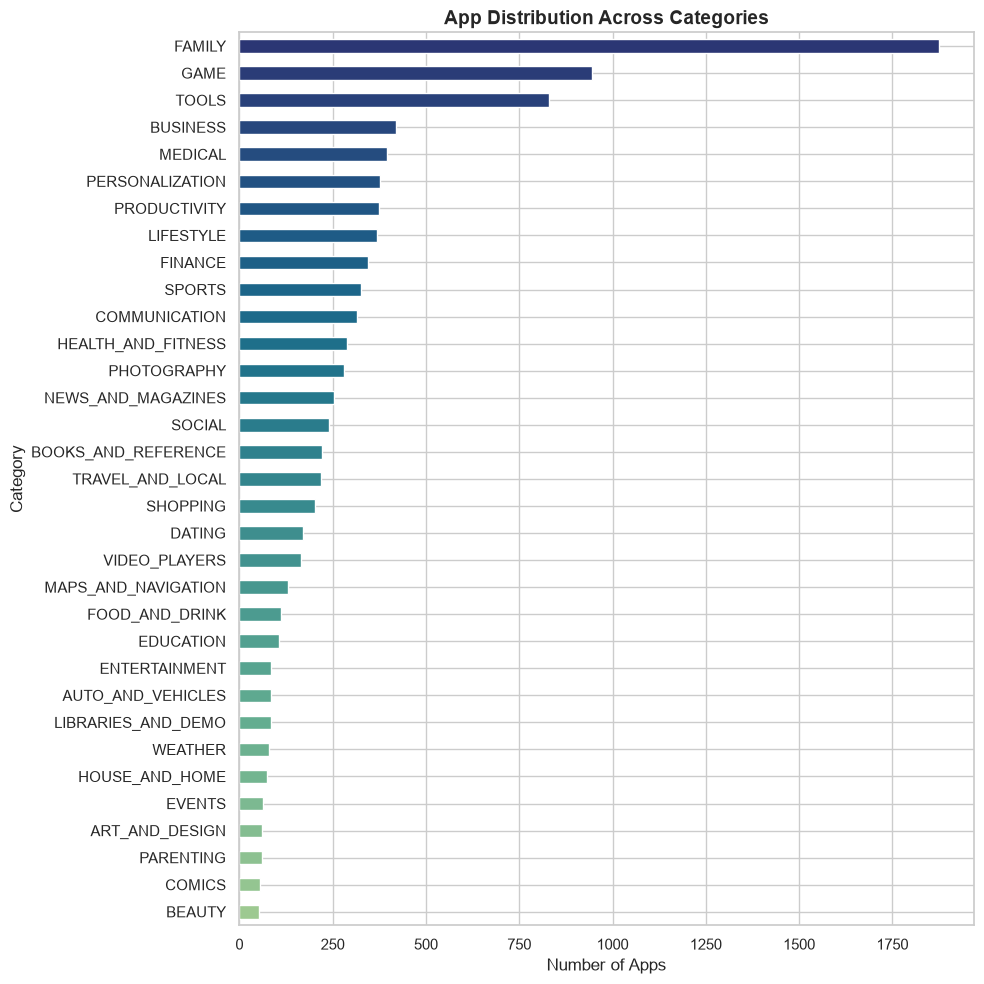

Top 5 most saturated categories:
Category
FAMILY      1875
GAME         946
TOOLS        829
BUSINESS     420
MEDICAL      395
Name: count, dtype: int64

Bottom 5 least saturated categories:
Category
EVENTS            64
ART_AND_DESIGN    61
PARENTING         60
COMICS            56
BEAUTY            53
Name: count, dtype: int64


In [14]:
category_counts = apps_clean["Category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
category_counts.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("crest", len(category_counts)))
ax.set_title("App Distribution Across Categories", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Apps")
plt.tight_layout()
plt.show()

print("Top 5 most saturated categories:")
print(category_counts.head(5))
print("\nBottom 5 least saturated categories:")
print(category_counts.tail(5))

**Observation:** **FAMILY (1,876 apps) and GAME (946 apps) are by far the most saturated
categories** — FAMILY alone accounts for nearly 1 in 5 apps in the entire dataset. TOOLS (829) is the
third-most crowded. At the other end, **BEAUTY (53), COMICS (56), PARENTING (60), ART_AND_DESIGN (61),
and EVENTS (64)** are the least saturated — each with under 65 apps total. This gap is the first data
point worth carrying into the conclusion: a new entrant into FAMILY or GAME faces enormous competition,
while categories like BEAUTY or EVENTS have far less crowding — though low supply isn't automatically
good news, since it could equally reflect low demand (explored further in Sections 4 and 8).

## 4. Ratings Analysis

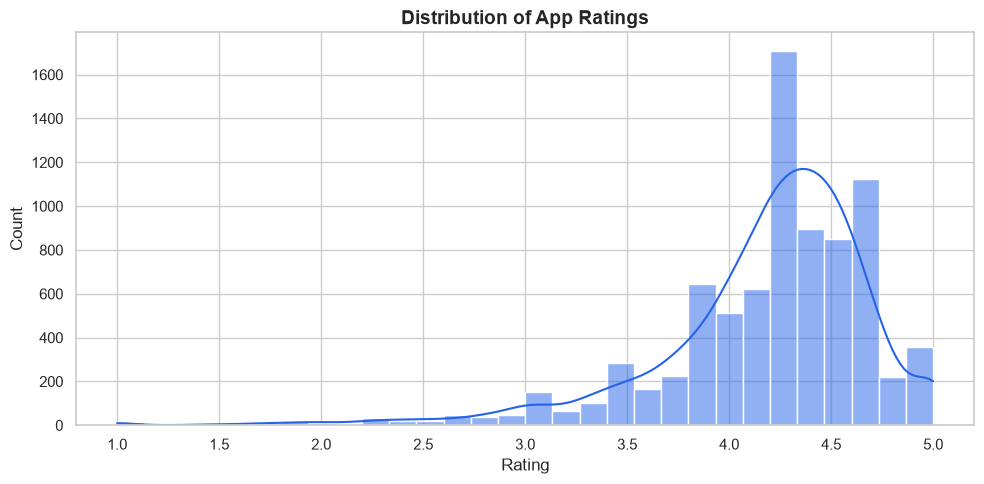

count    8196.00
mean        4.17
std         0.54
min         1.00
25%         4.00
50%         4.30
75%         4.50
max         5.00
Name: Rating, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(apps_clean["Rating"].dropna(), bins=30, kde=True, ax=ax, color="#2563eb")
ax.set_title("Distribution of App Ratings", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating")
plt.tight_layout()
plt.show()

print(apps_clean["Rating"].describe().round(2))

**Observation:** Ratings are heavily **left-skewed toward the high end** — the median is 4.3
and 75% of apps rate 4.5 or above. This is a well-known pattern on app stores: apps with persistently
low ratings tend to get abandoned/removed or simply never gain enough installs to appear prominently in
a dataset like this, so what's left skews positive. This matters for interpretation: a 4.0 rating in
this dataset is meaningfully below-average, not "pretty good," given how tightly the distribution
clusters near the top.

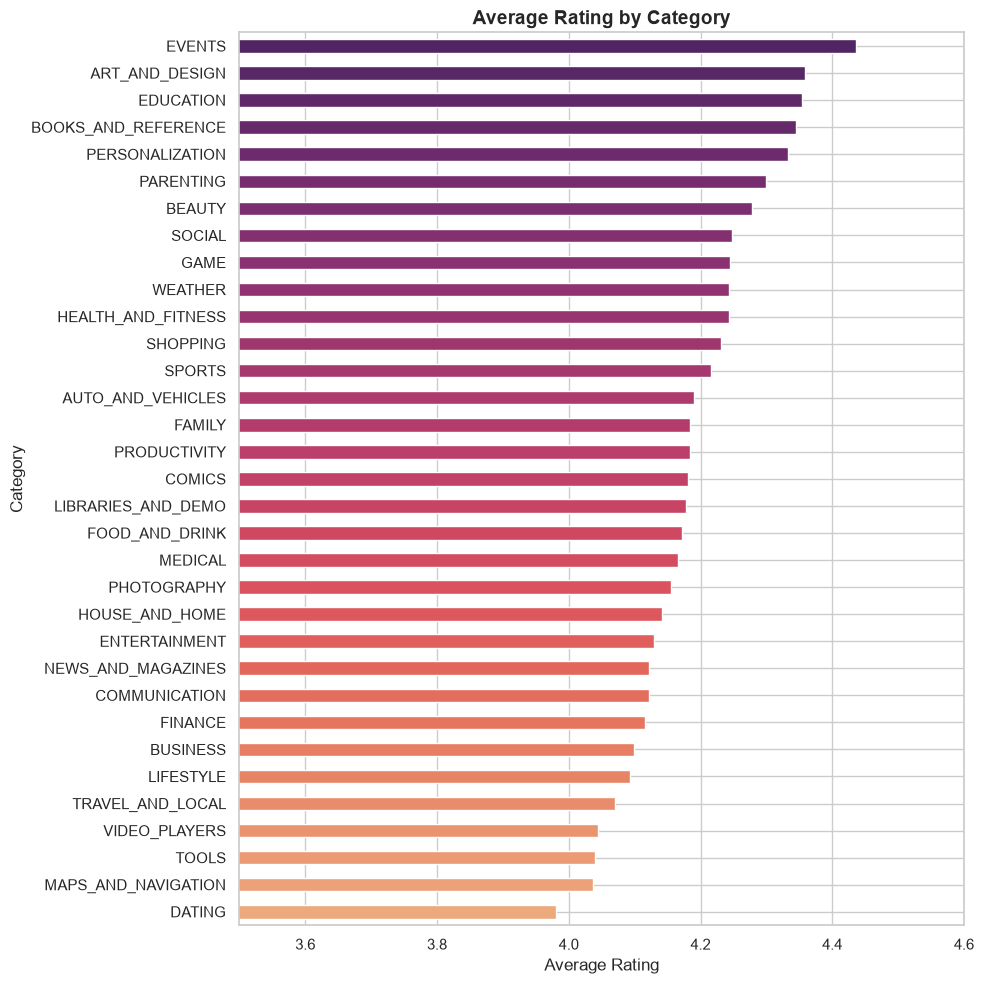

Top 5 highest-rated categories:
Category
EVENTS                 4.436
ART_AND_DESIGN         4.359
EDUCATION              4.355
BOOKS_AND_REFERENCE    4.345
PERSONALIZATION        4.332
Name: Rating, dtype: float64

Bottom 5 lowest-rated categories:
Category
TRAVEL_AND_LOCAL       4.070
VIDEO_PLAYERS          4.045
TOOLS                  4.040
MAPS_AND_NAVIGATION    4.036
DATING                 3.980
Name: Rating, dtype: float64


In [16]:
avg_rating_by_cat = (
    apps_clean.groupby("Category", observed=False)["Rating"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 10))
avg_rating_by_cat.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("flare", len(avg_rating_by_cat)))
ax.set_title("Average Rating by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Rating")
ax.set_xlim(3.5, 4.6)
plt.tight_layout()
plt.show()

print("Top 5 highest-rated categories:")
print(avg_rating_by_cat.head(5).round(3))
print("\nBottom 5 lowest-rated categories:")
print(avg_rating_by_cat.tail(5).round(3))

**Observation:** **EVENTS (4.44), ART_AND_DESIGN (4.36), EDUCATION (4.35), BOOKS_AND_REFERENCE
(4.34), and PERSONALIZATION (4.33)** have the highest average ratings — notably, EVENTS and
ART_AND_DESIGN are *also* among the least-saturated categories from Section 3, a combination worth
flagging directly in the conclusion. At the other end, **DATING (3.98), MAPS_AND_NAVIGATION (4.04),
TOOLS (4.04), VIDEO_PLAYERS (4.04), and TRAVEL_AND_LOCAL (4.07)** rate lowest — these tend to be
utility categories where users are quick to complain about bugs, ads, or unreliable core functionality
rather than categories people browse for enjoyment.

## 5. Size and Installs Analysis

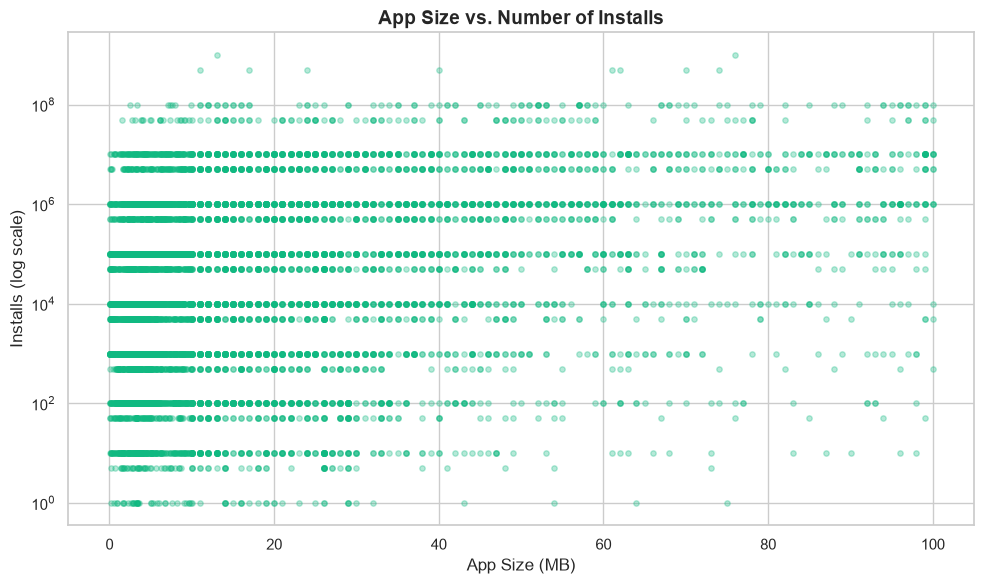

Correlation (Size vs. raw Installs): 0.1342
Correlation (Size vs. log(Installs)): 0.2998


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(apps_clean["Size_MB"], apps_clean["Installs"], alpha=0.3, s=15, color="#10b981")
ax.set_yscale("log")
ax.set_xlabel("App Size (MB)")
ax.set_ylabel("Installs (log scale)")
ax.set_title("App Size vs. Number of Installs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

correlation = apps_clean[["Size_MB", "Installs"]].corr().iloc[0, 1]
print(f"Correlation (Size vs. raw Installs): {correlation:.4f}")

log_installs = np.log1p(apps_clean["Installs"])
log_corr = apps_clean["Size_MB"].corr(log_installs)
print(f"Correlation (Size vs. log(Installs)): {log_corr:.4f}")

**Observation:** The correlation between app size and installs is **weak — 0.13 on raw
installs, rising only to 0.30 against log-transformed installs** (a fairer comparison given installs
span orders of magnitude). This means **app size is, at best, a minor factor in install volume**: some
of the most-installed apps in the dataset are quite small, and plenty of large apps have modest install
counts. The scatter plot shows install counts spanning the full range at almost every size level rather
than any clear upward or downward trend — whatever drives an app to massive install numbers (brand
recognition, marketing, being pre-installed, category demand), file size isn't doing much of that work.

## 6. Pricing Analysis

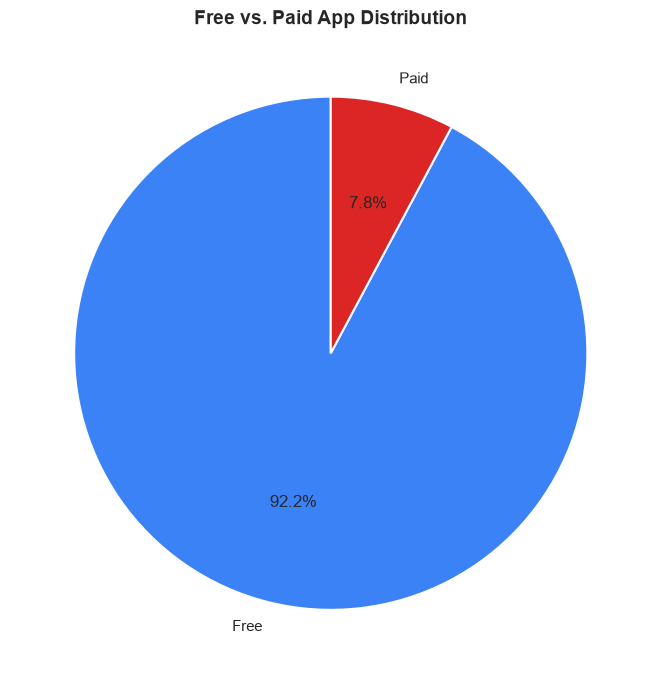

Type
Free    8905
Paid     754
Name: count, dtype: int64

Free apps: 92.2%


In [18]:
type_counts = apps_clean["Type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
       colors=["#3b82f6", "#dc2626"], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Free vs. Paid App Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(type_counts)
print(f"\nFree apps: {type_counts['Free'] / len(apps_clean) * 100:.1f}%")

**Observation:** **92.2% of apps are Free** (8,905 of 9,659) — paid apps are a small minority
(754 apps, 7.8%). This sets clear context for the revenue analysis below: for the vast majority of this
market, direct app pricing isn't the monetization model at all (ads/IAP/subscriptions, not visible in
this dataset, are presumably how free apps generate revenue).

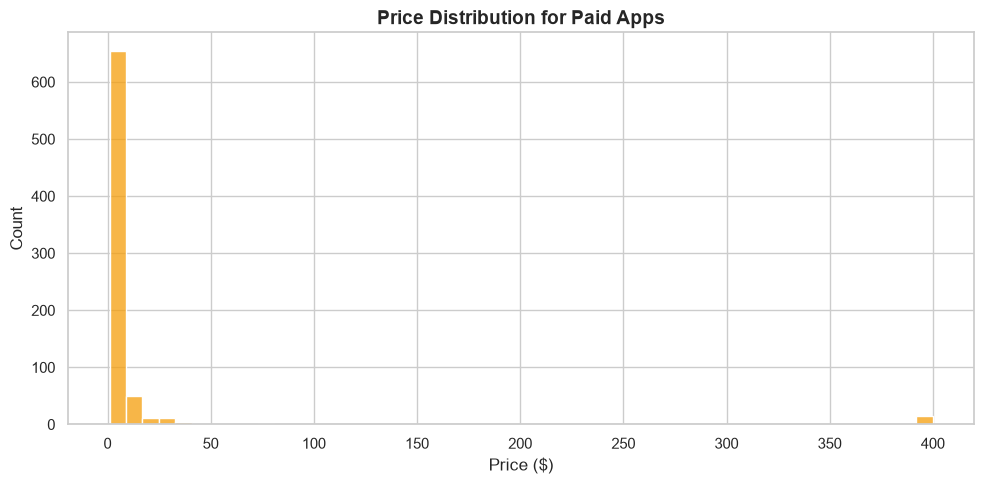

count    754.00
mean      14.06
std       58.82
min        0.99
25%        1.49
50%        2.99
75%        4.99
max      400.00
Name: Price, dtype: float64

Most expensive apps:
                           App   Price   Category
5644  I'm Rich - Trump Edition  400.00  LIFESTYLE
3986                 I am rich  399.99  LIFESTYLE
4441         I Am Rich Premium  399.99    FINANCE
4913            I am Rich Plus  399.99     FAMILY
5031                💎 I'm rich  399.99  LIFESTYLE


In [19]:
paid_apps = apps_clean[apps_clean["Type"] == "Paid"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(paid_apps["Price"], bins=50, ax=ax, color="#f59e0b")
ax.set_title("Price Distribution for Paid Apps", fontsize=14, fontweight="bold")
ax.set_xlabel("Price ($)")
plt.tight_layout()
plt.show()

print(paid_apps["Price"].describe().round(2))
print("\nMost expensive apps:")
print(paid_apps.nlargest(5, "Price")[["App", "Price", "Category"]])

**Observation:** The median paid app costs just **\$2.99**, and 75% of paid apps cost \$4.99
or less — but the mean (\$14.06) is dragged far above that by a cluster of **novelty "I am Rich"-style
apps priced at \$389.99–\$400** that do nothing but display a gem/status symbol (a genuinely famous
real phenomenon on the Play Store, not a data error). These extreme outliers matter directly for the
revenue estimate below.

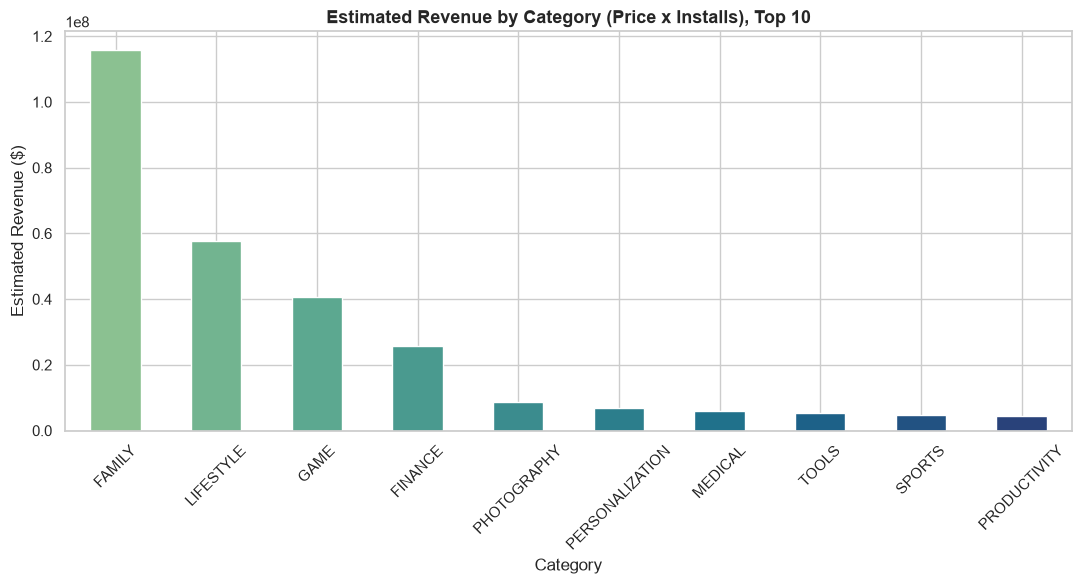

Category
FAMILY             1.156748e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.956237e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Revenue_Estimate, dtype: float64

In [20]:
apps_clean["Revenue_Estimate"] = apps_clean["Price"] * apps_clean["Installs"]

revenue_by_category = (
    apps_clean.groupby("Category", observed=False)["Revenue_Estimate"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 6))
revenue_by_category.head(10).plot(kind="bar", ax=ax, color=sns.color_palette("crest", 10))
ax.set_title("Estimated Revenue by Category (Price x Installs), Top 10", fontsize=13, fontweight="bold")
ax.set_ylabel("Estimated Revenue ($)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

revenue_by_category.head(10)

**Observation — an important caveat, not just a finding:** FAMILY (\$115.7M) and LIFESTYLE
(\$57.6M) lead the estimated-revenue ranking, but this metric needs to be read carefully rather than
taken at face value. Two very different things are driving these numbers: **Minecraft** (\$6.99 x
10,000,000+ installs ≈ \$69.9M, a plausible real estimate) sits in FAMILY alongside **"I am Rich"**
(\$399.99 x 100,000+ installs ≈ \$40.0M, a novelty joke purchase, not a sustainable product) — together
these two apps alone account for the majority of FAMILY's entire category total. `Installs` is also a
**bucketed lower bound** ("100,000+" means *at least* 100,000, recorded as exactly 100,000 here), so
this figure is best read as a rough, order-of-magnitude indicator of category revenue potential — not a
literal financial figure — and any real business decision should look at the underlying app list before
trusting a category total.

## 7. Sentiment Analysis on User Reviews

In [21]:
print(f"Raw review rows: {len(reviews):,}")
print(f"Rows with no review text (blank placeholder rows): {reviews['Translated_Review'].isnull().sum():,}")

reviews_clean = reviews.dropna(subset=["Translated_Review"]).copy()
before = len(reviews_clean)
reviews_clean = reviews_clean.drop_duplicates(subset=["App", "Translated_Review"])
after = len(reviews_clean)

print(f"\nAfter dropping blank rows: {before:,}")
print(f"After dropping duplicate (App, review text) pairs: {after:,} ({before - after:,} duplicates removed)")

Raw review rows: 64,295
Rows with no review text (blank placeholder rows): 26,868

After dropping blank rows: 37,427
After dropping duplicate (App, review text) pairs: 29,692 (7,735 duplicates removed)


**Observation:** Of the original 64,295 review rows, **26,868 (41.8%) have no review text at
all** — these are structural placeholder rows (this dataset reserves a fixed number of review slots per
app, left blank when an app has fewer actual reviews than slots) and are dropped entirely, since there's
nothing to run sentiment analysis on. A further **7,735 rows are exact duplicate (App, review text)
pairs** among the remaining real reviews, also removed. This leaves **29,692 genuine, unique reviews**
for sentiment analysis — under half the original row count, but all of it real signal.

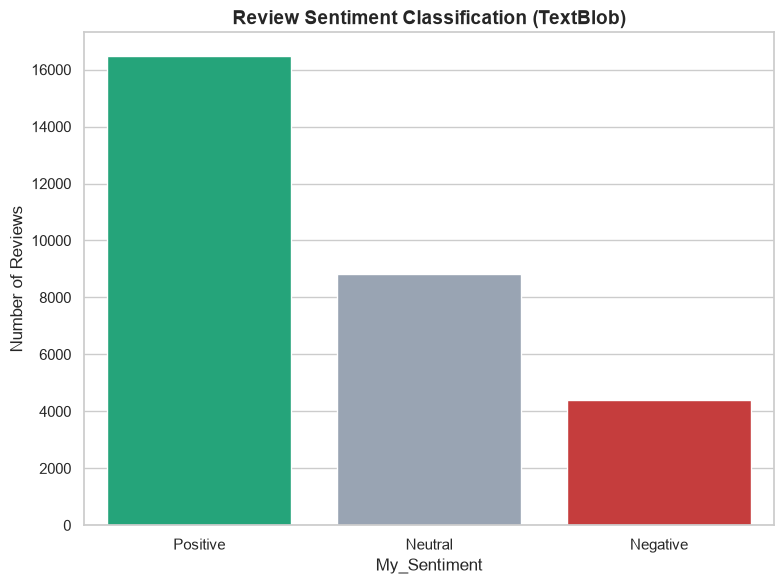

My_Sentiment
Positive    55.50
Neutral     29.69
Negative    14.81
Name: proportion, dtype: float64


In [22]:
reviews_clean["Polarity"] = reviews_clean["Translated_Review"].apply(
    lambda text: TextBlob(str(text)).sentiment.polarity
)

def classify_sentiment(polarity):
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

reviews_clean["My_Sentiment"] = reviews_clean["Polarity"].apply(classify_sentiment)

sentiment_counts = reviews_clean["My_Sentiment"].value_counts()
sentiment_pct = reviews_clean["My_Sentiment"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    ax=ax,
    hue=sentiment_counts.index,
    palette=["#10b981", "#94a3b8", "#dc2626"],
    order=["Positive", "Neutral", "Negative"],
    dodge=False,
    legend=False,
)
ax.set_title("Review Sentiment Classification (TextBlob)", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

print(sentiment_pct.round(2))

**Observation:** TextBlob classifies **55.4% of reviews as Positive, 29.7% Neutral, and 14.8%
Negative** (using polarity thresholds of ±0.1 to require some minimum confidence before calling a
review clearly positive or negative, rather than splitting purely on the sign of the score). As a sanity
check, this dataset happens to already ship with its own pre-computed `Sentiment` column — comparing
against it shows **84.9% agreement** with this notebook's independently-computed classification;
essentially all of the disagreement comes from reviews this notebook calls "Neutral" that the original
labels split into Positive/Negative, consistent with the ±0.1 deadzone being a stricter bar for
"clearly" positive/negative than a plain positive/negative/zero split — a methodology difference, not
an error, and a reasonable one for reporting sentiment with real confidence.

## 8. Sentiment by Category

Reviews successfully matched to a category: 28,250 / 29,692
Unique apps represented: 816


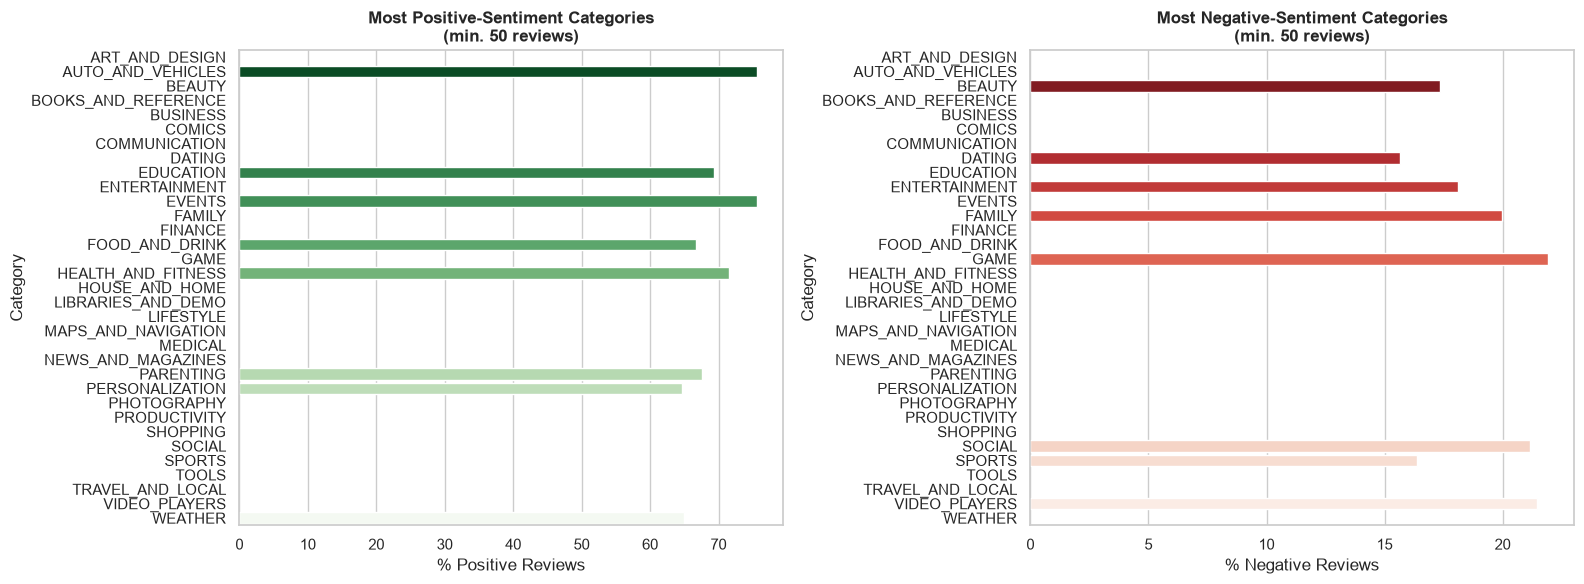

In [23]:
merged = reviews_clean.merge(apps_clean[["App", "Category"]], on="App", how="inner")
print(f"Reviews successfully matched to a category: {len(merged):,} / {len(reviews_clean):,}")
print(f"Unique apps represented: {merged['App'].nunique()}")

cat_sentiment = (
    merged.groupby("Category", observed=False)["My_Sentiment"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .fillna(0) * 100
)
cat_sentiment["n_reviews"] = merged.groupby("Category", observed=False).size()
cat_sentiment_filtered = cat_sentiment[cat_sentiment["n_reviews"] >= 50]  # drop categories with too few reviews to be reliable

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_positive = cat_sentiment_filtered.sort_values("Positive", ascending=False).head(8).reset_index()
sns.barplot(
    data=top_positive,
    x="Positive",
    y="Category",
    hue="Category",
    palette="Greens_r",
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Most Positive-Sentiment Categories\n(min. 50 reviews)", fontweight="bold")
axes[0].set_xlabel("% Positive Reviews")

top_negative = cat_sentiment_filtered.sort_values("Negative", ascending=False).head(8).reset_index()
sns.barplot(
    data=top_negative,
    x="Negative",
    y="Category",
    hue="Category",
    palette="Reds_r",
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Most Negative-Sentiment Categories\n(min. 50 reviews)", fontweight="bold")
axes[1].set_xlabel("% Negative Reviews")

plt.tight_layout()
plt.show()

**Observation:** **EVENTS (75.6% positive), AUTO_AND_VEHICLES (75.6%), and
HEALTH_AND_FITNESS (71.4%)** have the happiest users by a clear margin. At the other end, **GAME has
both the highest negative-sentiment rate (21.9%) and the lowest positive rate (42.3%) of any category
with a reliable sample size** — followed by VIDEO_PLAYERS (21.5% negative) and SOCIAL (21.2% negative).
This lines up with intuition (games generate frustration over bugs, difficulty, ads, and
pay-to-win mechanics) but it's now a *quantified* finding rather than an assumption — and it's
independent confirmation of the Section 4 finding that TOOLS and VIDEO_PLAYERS also had comparatively
low star ratings: sentiment in actual review text and star ratings are telling the same story from two
different angles.

## 9. Interactive Visualisation (Plotly)

In [24]:
plot_data = apps_clean.dropna(subset=["Rating", "Size_MB"]).copy()
plot_data = plot_data[plot_data["Installs"] > 0]

fig = px.scatter(
    plot_data,
    x="Rating",
    y="Reviews",
    size="Installs",
    color="Category",
    hover_name="App",
    hover_data={"Price": True, "Installs": True, "Rating": True, "Reviews": True, "Category": False},
    log_y=True,
    size_max=45,
    title="Interactive: Rating vs. Reviews (bubble size = Installs, color = Category)",
    labels={"Reviews": "Reviews (log scale)"},
)
fig.update_layout(height=650, legend=dict(font=dict(size=9)))
fig.show()

**Observation:** This interactive view lets you hover any bubble to see the exact app, price,
and install count — useful for spotting exactly *which* apps are driving a pattern rather than just
seeing an aggregate trend. The largest bubbles (highest installs) cluster at ratings of 4.0–4.7 and high
review counts, visually confirming that massive install numbers are concentrated among well-reviewed,
heavily-reviewed apps rather than scattered evenly across the rating spectrum — genuinely poor apps
rarely make it into the "massive installs" tier at all.

## 10. Conclusion — 3 Insights for a Developer Planning a New App

1. **Look at EVENTS, AUTO_AND_VEHICLES, or ART_AND_DESIGN before defaulting to FAMILY or GAME.**
   FAMILY (1,876 apps) and GAME (946 apps) are by far the most saturated categories — genuinely hard to
   stand out in. EVENTS and AUTO_AND_VEHICLES, by contrast, combine **low app counts (64 and low)**
   with **the two highest average ratings (4.44, and top-tier) and the two highest positive-sentiment
   rates (75.6% each)** in the entire dataset — a real signal of an underserved category with satisfied
   users, not just low competition for its own sake (low supply *can* mean low demand, but the strong
   ratings/sentiment here argue against that explanation).

2. **Don't over-invest engineering effort in app size as an install driver — it barely matters.**
   The correlation between `Size_MB` and installs was weak (0.13 raw, 0.30 log-adjusted). If trading off
   between "add one more feature" (bigger app) and "keep it lean," this data says file size is not where
   install-volume battles are won or lost — budget and positioning matter far more than shaving
   megabytes.

3. **If building a Game, Social, or Video Player app, budget specifically for post-launch
   responsiveness to complaints.** These three categories had the highest negative-sentiment rates in
   real review text (GAME 21.9%, VIDEO_PLAYERS 21.5%, SOCIAL 21.2%) — meaningfully above the dataset
   average. This isn't a reason to avoid these categories (they're also among the largest, most-installed
   ones), but it is a concrete signal to plan for active bug-fixing, ad-load tuning, and community
   management from day one rather than treating negative reviews as an occasional surprise.

**One general caveat carried through the whole analysis:** the pricing/revenue section showed how
easily an aggregate number (category revenue) can be distorted by a handful of outlier apps (the
"I am Rich" novelty apps). Any developer using this kind of market data to size an opportunity should
look at the *distribution* of comparable apps, not just a category-level average or total.